# CalculiX results: `.frd`

[CalculiX](http://www.dhondt.de/) reads Abaqus-style `.inp` input, which meshio++ already writes, and its solver `ccx` answers with a `.frd` result file. meshio++ reads it, so the whole open-source chain runs without a proprietary tool: **mesh → `.inp` → `ccx` → `.frd` → `.vtu` / VTKHDF**.

Every increment of the file is a **step** of the sequence engine, each `-4` result becomes a `point_data` array under the name the file gives it (`DISP`, `STRESS`, `TOSTRAIN`, `NDTEMP`, ...), and the two engines (C++ core and Python reference) read the same files identically. `.frd` is read-only: it is what a solver writes.

The files used here are in `tests/python/meshes/frd/`. They were written by `ccx` 2.23 from the decks next to them (`tools/gen_frd_fixtures.py` regenerates them); the beam is a 6 × 1 × 1 cantilever of 12 × 2 × 2 `C3D8I` elements, clamped at one end.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

FRD = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes', 'frd')
TMP = tempfile.mkdtemp()


def to_grid(mesh, scale=0.0):
    """A PyVista grid of `mesh`, its points moved by `scale * DISP`."""
    points = mesh.points + scale * mesh.point_data['DISP'] if scale else mesh.points
    path = os.path.join(TMP, 'render.vtu')
    mp.write(path, mp.Mesh(points, mesh.cells, point_data=mesh.point_data))
    return pv.read(path)


def gallery(items, ncols=2, size=(880, 420)):
    """Render `(mesh, scalar, title, scale, clim, camera)` items side by side, or with matplotlib when GL is unavailable."""
    nrows = -(-len(items) // ncols)
    fig = plt.figure(figsize=(6.2 * ncols, 3.2 * nrows))
    for k, (mesh, scalar, title, scale, clim, camera) in enumerate(items, start=1):
        try:
            grid = to_grid(mesh, scale)
            pl = pv.Plotter(off_screen=True, window_size=size)
            pl.add_mesh(grid, scalars=scalar, cmap='turbo', clim=clim, show_edges=True, edge_color='#333333',
                        line_width=0.6, scalar_bar_args={'title': scalar, 'vertical': False,
                                                        'position_x': 0.2, 'position_y': 0.05, 'width': 0.6})
            pl.camera_position = camera
            pl.camera.zoom(0.9)
            img = pl.screenshot(return_img=True)
            pl.close()
            ax = fig.add_subplot(nrows, ncols, k)
            ax.imshow(img)
        except Exception as exc:  # pragma: no cover - head-less GL fallback
            print('PyVista render skipped:', exc)
            ax = fig.add_subplot(nrows, ncols, k, projection='3d')
            p = mesh.points + scale * mesh.point_data['DISP'] if scale else mesh.points
            values = mesh.point_data[scalar]
            values = np.linalg.norm(values, axis=1) if values.ndim > 1 else values
            ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=8, c=values, cmap='turbo')
        ax.set_title(title, fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Read a result file

`read_metadata` lists the increments without materializing anything: this file has two load steps. `read` returns the first by default, `time_step=-1` the last, and the step's value, step counter and analysis type ride along as field data.

In [2]:
static = os.path.join(FRD, 'cantilever_static.frd')
meta = mp.read_metadata(static)
print('format', meta['format'], '| steps', meta['time_values'])

first = mp.read(static)
print(first)
print()
for name, values in first.point_data.items():
    print(f'{name:9s} {str(values.shape):9s} {values.dtype}')
print({k: v.tolist() for k, v in first.field_data.items()})

format frd | steps [1.0, 2.0]
<meshio++ mesh object>
  Number of points: 117
  Number of cells:
    hexahedron: 48
  Point data: DISP, ERROR, STRESS, TOSTRAIN
  Cell data: frd:group, frd:material
  Field data: frd:analysis, frd:step, meshio:time

DISP      (117, 3)  float64
ERROR     (117,)    float64
STRESS    (117, 6)  float64
TOSTRAIN  (117, 6)  float64
{'frd:analysis': [0], 'frd:step': [1], 'meshio:time': [1.0]}


`DISP` is `(n, 3)`, and the six components of `STRESS` and `TOSTRAIN` keep the file's order `xx yy zz xy yz zx`, which is also VTK's. `ERROR` is CalculiX's own error estimate. The component the file marks as calculated (the `ALL` of `DISP`) is not data and is dropped.

## Deformed shape, coloured by von Mises

The file holds the stress tensor, not its invariants. `derived=True` on the format's reader adds `STRESS_mises` and `STRESS_principal` (ascending min, mid, max) with the formula of [ccx2paraview](https://github.com/calculix/ccx2paraview). The tip carries a shear load, and the second step doubles it: a linear model, so the second picture is the first one twice as deep.

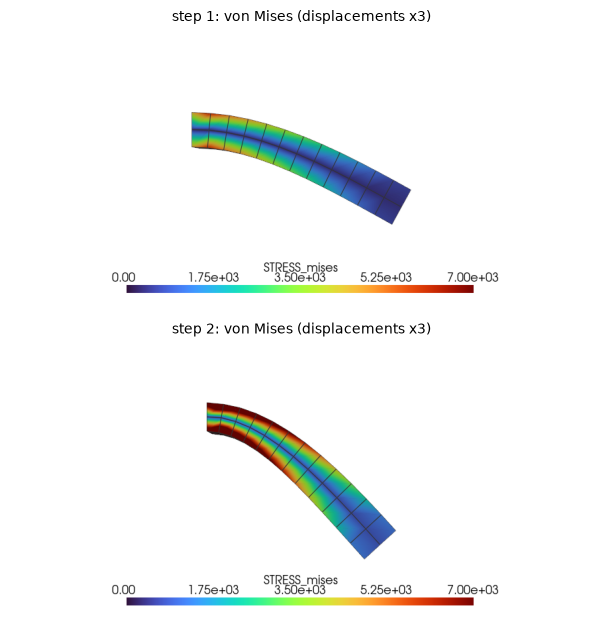

In [3]:
steps = [mp.frd.read(static, time_step=i, derived=True) for i in (0, 1)]
scale = 3.0
items = [(m, 'STRESS_mises', f'step {i + 1}: von Mises (displacements x{scale:g})', scale, (0, 7000), 'xz')
         for i, m in enumerate(steps)]
gallery(items, ncols=1)

A cantilever of length `L`, section modulus `I = b h³ / 12` and tip load `P` deflects by `P L³ / (3 E I)` (Euler-Bernoulli). The 9 tip nodes carry 20 N each in the first step:

In [4]:
E, L, I, P = 210000.0, 6.0, 1.0 / 12.0, 9 * 20.0
beam_theory = P * L**3 / (3 * E * I)
for i, m in enumerate(steps):
    tip = np.isclose(m.points[:, 0], L)
    uz = -m.point_data['DISP'][tip, 2].mean()
    print(f'step {i + 1}: tip deflection {uz:.4f}   beam theory {beam_theory * (i + 1):.4f}   ratio {uz / (beam_theory * (i + 1)):.4f}')

step 1: tip deflection 0.7387   beam theory 0.7406   ratio 0.9975
step 2: tip deflection 1.4774   beam theory 1.4811   ratio 0.9975


## Frequency steps: the modes of the beam

In a frequency analysis every mode is an increment. The value is the **frequency** in cycles per time unit (the FREQUENCY column of `ccx`'s own table), and `frd:analysis` is `2`. A square section bends the same way about both axes, so modes 1 and 2 (and 3 and 4) have the same frequency: the reader tells the increments apart by their frame id as well as their value.

frequencies (Hz): [23158.00422, 23158.00422, 131775.7516, 131775.7516]
first bending mode, beam theory: 23283 Hz   read: 23158 Hz
mode 1: frd:step 1  analysis 2  23158.0 Hz
mode 2: frd:step 2  analysis 2  23158.0 Hz
mode 3: frd:step 3  analysis 2  131775.8 Hz
mode 4: frd:step 4  analysis 2  131775.8 Hz


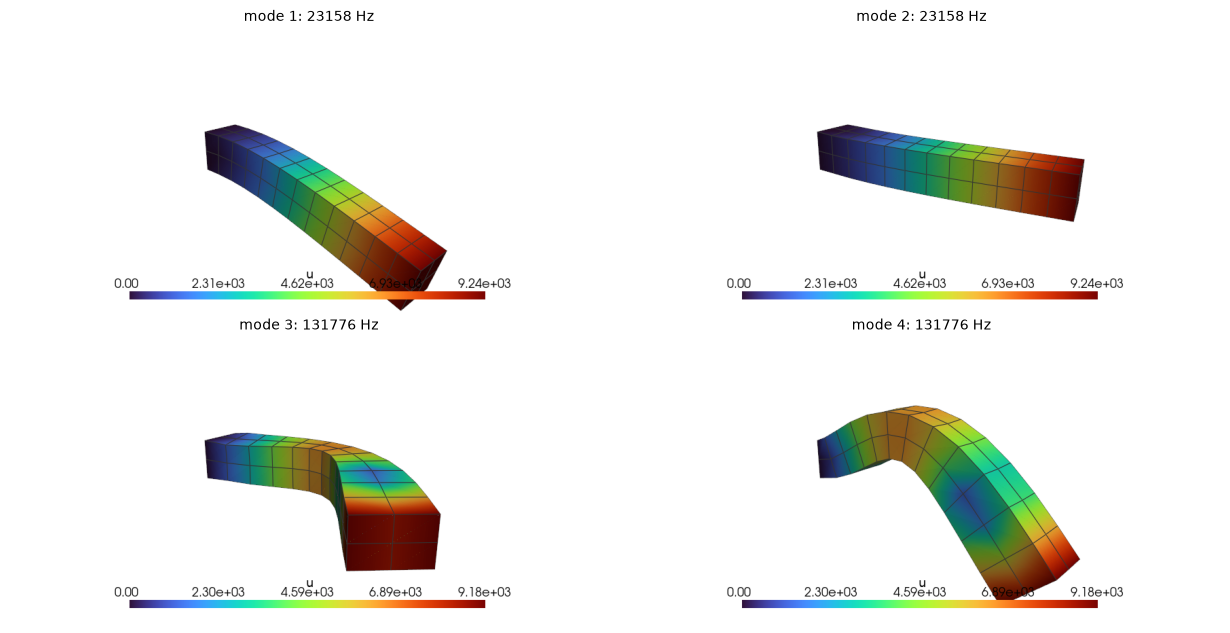

In [5]:
modes_file = os.path.join(FRD, 'cantilever_modes.frd')
freqs = mp.read_metadata(modes_file)['time_values']
mass_per_length = 7.8e-9 * 1.0
f1 = 1.8751**2 / (2 * np.pi * L**2) * np.sqrt(E * I / mass_per_length)
print('frequencies (Hz):', freqs)
print(f'first bending mode, beam theory: {f1:.0f} Hz   read: {freqs[0]:.0f} Hz')

modes = []
for i in range(4):
    m = mp.read(modes_file, time_step=i)
    u = np.linalg.norm(m.point_data['DISP'], axis=1)
    m.point_data['|u|'] = u
    modes.append(m)
    print(f"mode {i + 1}: frd:step {m.field_data['frd:step'][0]}  analysis {m.field_data['frd:analysis'][0]}  {m.field_data['meshio:time'][0]:.1f} Hz")
ISO = [(9.5, -7, 4), (3, 0.5, 0.5), (0, 0, 1)]
gallery([(m, '|u|', f"mode {i + 1}: {freqs[i]:.0f} Hz", 1.5 / m.point_data['|u|'].max(), None, ISO)
         for i, m in enumerate(modes)])

## Steps are sequences

Because the increments are steps, the sequence engine walks them like any other multi-step file, and a `{step}` token in the output writes one file each. A single-file output for a multi-step input is refused by name rather than truncated to the first step:

In [6]:
series = [(t, m) for t, m in mp.read_sequence(modes_file)]
print([round(t) for t, _ in series], 'Hz')

written = mp.write_sequence(os.path.join(TMP, 'mode_{step}.vtu'), series)
print([os.path.basename(p) for p in written])
try:
    mp.write_sequence(os.path.join(TMP, 'modes.vtu'), series)
except Exception as exc:
    print(type(exc).__name__ + ':', exc)
print([os.path.basename(p) for p in mp.write_sequence(os.path.join(TMP, 'modes.xdmf'), series)])

[23158, 23158, 131776, 131776] Hz
['mode_0000.vtu', 'mode_0001.vtu', 'mode_0002.vtu', 'mode_0003.vtu']
WriteError: meshio++: sequence: format 'vtu' cannot hold a multi-step series (only 'xdmf' / 'gid' / 'usd' / 'vtkhdf' / 'pvd' can); write one file per step with an output path containing '{step}' instead
['modes.xdmf']


## Shells and beams come back as solids

`ccx` expands shells and beams into solids before it writes the results, so the mesh in a `.frd` is **not** the mesh in the `.inp`. An 8-node shell (`S8`) has 8 nodes in the deck and comes back as a 20-node brick; a truss (`T3D3`) is left alone.

In [7]:
def deck_type(name):
    with open(os.path.join(FRD, 'decks', name + '.inp')) as f:
        return next(line.split('TYPE=')[1].split(',')[0].strip() for line in f if line.startswith('*ELEMENT'))


print(f"{'deck element':>14s}  {'deck nodes':>10s}   {'result cell':<14s} {'result nodes':>12s}")
for name, deck_nodes in (('s3', 3), ('s4', 4), ('s6', 6), ('s8', 8), ('b31', 2), ('t3d3', 3), ('c3d15', 15)):
    m = mp.read(os.path.join(FRD, name + '.frd'))
    print(f'{deck_type(name):>14s}  {deck_nodes:10d}   {m.cells[0].type:<14s} {len(m.points):12d}')

  deck element  deck nodes   result cell    result nodes
            S3           3   wedge                     6
            S4           4   hexahedron                8
            S6           6   wedge15                  15
            S8           8   hexahedron20             20
           B31           2   hexahedron                8
          T3D3           3   line3                     3
         C3D15          15   wedge15                  15


## Node order

The 20-node brick, the 15-node wedge and the 3-node line list their nodes in a different order in a `.frd` than in Abaqus (and so in meshio++): the vertical mid-edge nodes of the brick and the wedge come *before* the top ring, and the mid node of a line sits second. The reader permutes them, and the check is geometric: after the permutation every mid-edge node lies on the middle of its edge.

In [8]:
EDGES = {
    'hexahedron20': (8, [(0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4), (0, 4), (1, 5), (2, 6), (3, 7)]),
    'wedge15': (6, [(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3), (0, 3), (1, 4), (2, 5)]),
    'line3': (2, [(0, 1)]),
}
print(f"{'file':8s} {'cell type':14s} {'largest mid-node error':>24s}")
for name in ('c3d20', 's8', 'c3d15', 's6', 't3d3'):
    m = mp.read(os.path.join(FRD, name + '.frd'))
    corners, edges = EDGES[m.cells[0].type]
    row = m.cells[0].data[0]
    err = max(np.abs(m.points[row[corners + k]] - (m.points[row[a]] + m.points[row[b]]) / 2).max()
              for k, (a, b) in enumerate(edges))
    print(f'{name:8s} {m.cells[0].type:14s} {err:24.2e}')

file     cell type        largest mid-node error
c3d20    hexahedron20                   0.00e+00
s8       hexahedron20                   0.00e+00
c3d15    wedge15                        0.00e+00
s6       wedge15                        0.00e+00
t3d3     line3                          0.00e+00


## The short layout and the cgx shell types

`ccx` always writes the long layout (`I10` ids) and never the cgx shell types 7 to 10. A hand-written file exercises both: `I5` ids, a `qu4`, a `qu8`, a `tr3` and a `tr6`, an eight-component result that continues on a second line, and a second increment that only has values for six nodes. The nodes a result does not cover are NaN.

In [9]:
short = mp.read(os.path.join(FRD, 'cgx_short.frd'))
print([(b.type, b.data.shape[1]) for b in short.cells])
print('group', [a.tolist() for a in short.cell_data['frd:group']], ' material', [a.tolist() for a in short.cell_data['frd:material']])
print('WIDE', short.point_data['WIDE'].shape, ' first row', short.point_data['WIDE'][0])

late = mp.read(os.path.join(FRD, 'cgx_short.frd'), time_step=-1)
print('NDTEMP at step', late.field_data['meshio:time'][0], late.point_data['NDTEMP'])

[('quad', 4), ('quad8', 8), ('triangle', 3), ('triangle6', 6)]
group [[2], [0], [0], [0]]  material [[3], [1], [1], [1]]
WIDE (21, 8)  first row [ 6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5]
NDTEMP at step 1.5 [21. 22. 23. 24. 25. 26. nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan]


## Derived fields against a plain NumPy check

`STRESS_mises` is `sqrt(½((xx−yy)² + (yy−zz)² + (zz−xx)²) + 3(xy² + yz² + zx²))` and `STRESS_principal` the ascending eigenvalues of the symmetric tensor. Both engines compute them, and a NumPy version reproduces them:

In [10]:
m = steps[-1]
s = m.point_data['STRESS']
tensor = np.empty((len(s), 3, 3))
for i, (xx, yy, zz, xy, yz, zx) in enumerate(s):
    tensor[i] = [[xx, xy, zx], [xy, yy, yz], [zx, yz, zz]]
principal = np.linalg.eigvalsh(tensor)
mises = np.sqrt(0.5 * (principal[:, 0] - principal[:, 1]) ** 2 + 0.5 * (principal[:, 1] - principal[:, 2]) ** 2
                + 0.5 * (principal[:, 2] - principal[:, 0]) ** 2)
print('max |mises - numpy|     ', np.abs(m.point_data['STRESS_mises'] - mises).max())
print('max |principal - numpy| ', np.abs(m.point_data['STRESS_principal'] - principal).max())
print('peak von Mises', round(float(m.point_data['STRESS_mises'].max()), 1), 'at x =', m.points[m.point_data['STRESS_mises'].argmax(), 0])

max |mises - numpy|      3.637978807091713e-12
max |principal - numpy|  5.4569682106375694e-12
peak von Mises 12392.6 at x = 0.5


## Onward: to ParaView

The same results are one command away from any other meshio++ format, from either CLI:

```sh
meshioplusplus convert --time-step=-1 cantilever_static.frd last.vtu
meshioplusplus convert cantilever_modes.frd 'mode_{step}.vtu'      # one file per increment
meshioplusplus info cantilever_static.frd
```

The limits are spelled out in the [CalculiX format page](../../doc/formats/frd.md): binary `.frd` and the `.dat` tabular file are not read, only nodal results are, and `derived=` is an argument of the format's own reader, not of the CLI.